# Support Vector Machines 

Welcome to your SVM assignment! Just follow along with the notebook and instructions below. We will be analyzing the famous iris data set!

## The Data
For this series of lectures, we will be using the famous [Iris flower data set](http://en.wikipedia.org/wiki/Iris_flower_data_set). 

The Iris flower data set or Fisher's Iris data set is a multivariate data set introduced by Sir Ronald Fisher in the 1936 as an example of discriminant analysis. 

The data set consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor), so 150 total samples. Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

Here's a picture of the three different Iris types:

In [6]:
# # The Iris Setosa
from IPython.display import Image, display
url = 'http://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg'
display(Image(url=url, width=300, height=300))

In [7]:
# The Iris Versicolor
url = 'http://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg'
display(Image(url=url, width=300, height=300))

In [8]:
# The Iris Virginica
url = 'http://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg'
display(Image(url=url, width=300, height=300))

The iris dataset contains measurements for 150 iris flowers from three different species.

The three classes in the Iris dataset:

    Iris-setosa (n=50)
    Iris-versicolor (n=50)
    Iris-virginica (n=50)

The four features of the Iris dataset:

    sepal length in cm
    sepal width in cm
    petal length in cm
    petal width in cm

## Get the data

**Use seaborn to get the iris data by using: iris = sns.load_dataset('iris') **

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris_data = load_iris()
iris = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
iris['species'] = pd.Categorical.from_codes(iris_data.target, iris_data.target_names)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Let's visualize the data and get you started!

## Exploratory Data Analysis

Time to put your data viz skills to the test! Try to recreate the following plots, make sure to import the libraries you'll need!

**Import some libraries you think you'll need.**

In [3]:
%matplotlib inline
sns.set(style='whitegrid')

print('Data shape:', iris.shape)
iris['species'].value_counts()

Data shape: (150, 5)


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

** Create a pairplot of the data set. Which flower species seems to be the most separable?**

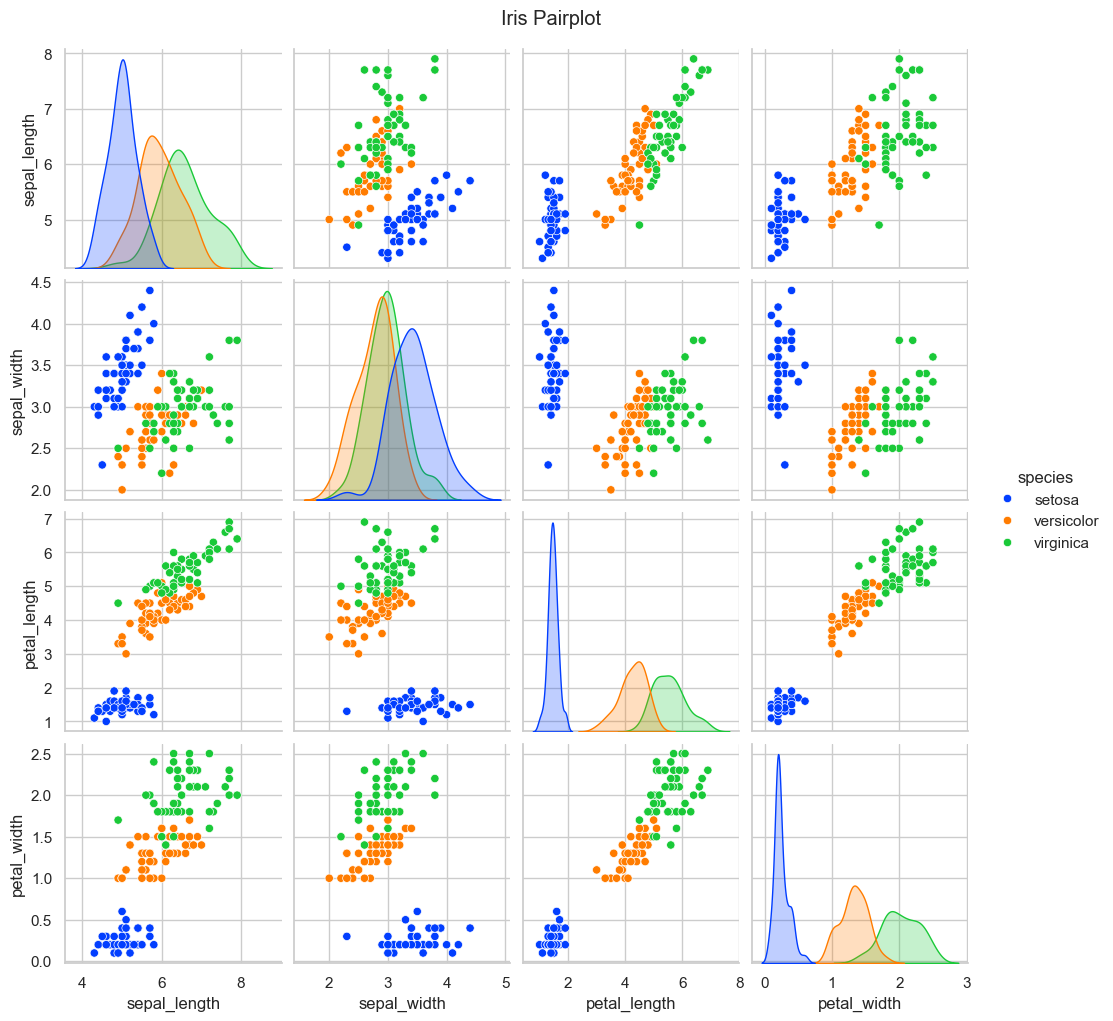

In [4]:
sns.pairplot(iris, hue='species', palette='bright')
plt.suptitle('Iris Pairplot', y=1.02)
plt.show()

**Create a kde plot of sepal_length versus sepal width for setosa species of flower.**

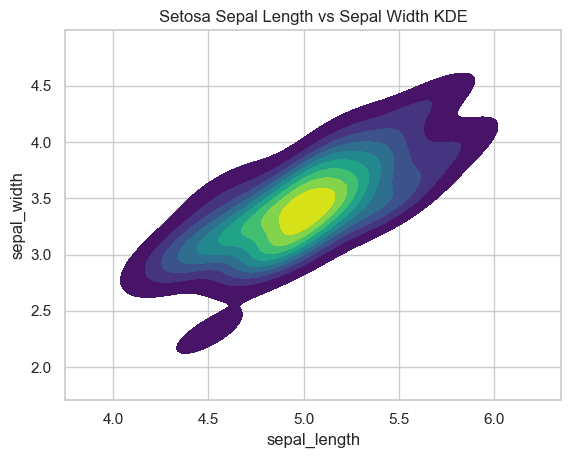

In [5]:
setosa = iris[iris['species'] == 'setosa']

sns.kdeplot(data=setosa, x='sepal_length', y='sepal_width', fill=True, cmap='viridis', thresh=0.05)
plt.title('Setosa Sepal Length vs Sepal Width KDE')
plt.show()

# Train Test Split

** Split your data into a training set and a testing set.**

In [6]:
from sklearn.model_selection import train_test_split

X = iris.drop('species', axis=1)
y = iris['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101, stratify=y)

In [7]:
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train distribution:\n', y_train.value_counts())
print('y_test distribution:\n', y_test.value_counts())

X_train shape: (105, 4)
X_test shape: (45, 4)
y_train distribution:
 species
setosa        35
versicolor    35
virginica     35
Name: count, dtype: int64
y_test distribution:
 species
setosa        15
versicolor    15
virginica     15
Name: count, dtype: int64


# Train a Model

Now its time to train a Support Vector Machine Classifier. 

**Call the SVC() model from sklearn and fit the model to the training data.**

In [8]:
from sklearn.svm import SVC

In [9]:
svc = SVC()
svc.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
predictions = svc.predict(X_test)
print('Sample predictions:', predictions[:10])

Sample predictions: ['virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'virginica'
 'virginica' 'virginica' 'setosa' 'versicolor']


## Model Evaluation

**Now get predictions from the model and create a confusion matrix and a classification report.**

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [12]:
print('Accuracy:', accuracy_score(y_test, predictions))
print('\nClassification Report:\n', classification_report(y_test, predictions))

Accuracy: 0.9555555555555556

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.87      0.93        15
   virginica       0.88      1.00      0.94        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



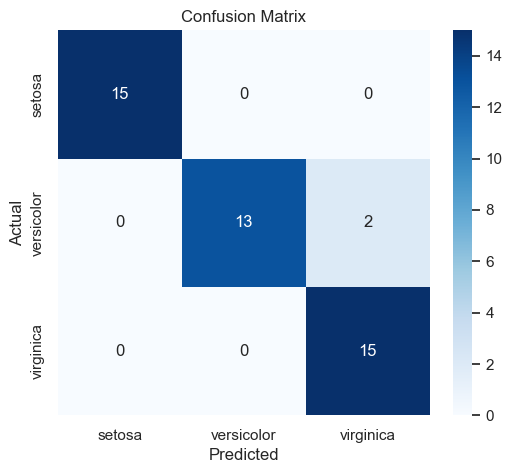

In [13]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=svc.classes_, yticklabels=svc.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [14]:
print('Support vectors shape:', svc.support_vectors_.shape)
print('Number of support vectors for each class:', svc.n_support_)

Support vectors shape: (51, 4)
Number of support vectors for each class: [ 7 24 20]


Wow! You should have noticed that your model was pretty good! Let's see if we can tune the parameters to try to get even better (unlikely, and you probably would be satisfied with these results in real like because the data set is quite small, but I just want you to practice using GridSearch.

## Gridsearch Practice

** Import GridsearchCV from SciKit Learn.**

In [15]:
from sklearn.model_selection import GridSearchCV

**Create a dictionary called param_grid and fill out some parameters for C and gamma.**

In [16]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

** Create a GridSearchCV object and fit it to the training data.**

In [17]:
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)
print('Best parameters:', grid.best_params_)
print('Best cross-validation score:', grid.best_score_)

Best parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best cross-validation score: 0.9714285714285715


** Now take that grid model and create some predictions using the test set and create classification reports and confusion matrices for them. Were you able to improve?**

In [18]:
grid_predictions = grid.predict(X_test)
print('Grid Test Accuracy:', accuracy_score(y_test, grid_predictions))
print('\nGrid Classification Report:\n', classification_report(y_test, grid_predictions))

Grid Test Accuracy: 0.9333333333333333

Grid Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



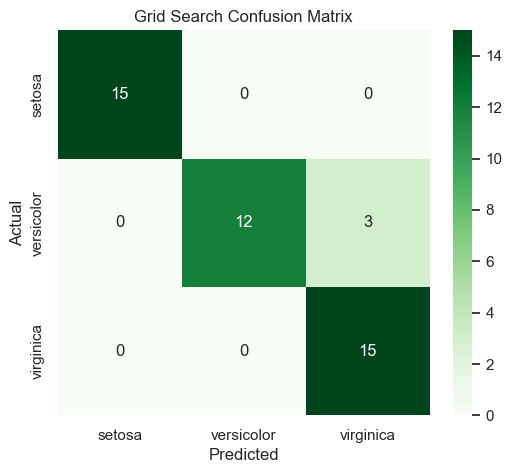

In [19]:
cm_grid = confusion_matrix(y_test, grid_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm_grid, annot=True, fmt='d', cmap='Greens', xticklabels=grid.best_estimator_.classes_, yticklabels=grid.best_estimator_.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Grid Search Confusion Matrix')
plt.show()

In [20]:
print('Best estimator:', grid.best_estimator_)
print('Improved over default model?', accuracy_score(y_test, grid_predictions) > accuracy_score(y_test, predictions))

Best estimator: SVC(C=1, gamma=1)
Improved over default model? False
